# A numerical demonstration of a photonic neural network implementing a XOR gate with _neuroptica_

In [1]:
!pip install neuroptica


[notice] A new release of pip is available: 23.3.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import neuroptica as neu
import numpy as np
import matplotlib.pyplot as plt

/u/sw/toolchains/gcc-glibc/11.2.0/pkgs/scipy/1.7.0/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 2.0.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
!pip install --upgrade numpy


[notice] A new release of pip is available: 23.3.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


### Creating the XOR dataset

The XOR gate has the following input-output mapping:
- $[0, 0] → 0$
- $[0, 1] → 1$
- $[1, 0] → 1$
- $[1, 1] → 0$

In [3]:
# Define XOR inputs and targets.
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.int32)

T = np.array([0, 1, 1, 0], dtype=np.int32)

print("XOR Dataset:")
print("Inputs:\n", X_xor)
print("\nTargets:", T)

XOR Dataset:
Inputs:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]

Targets: [0 1 1 0]


### Specify the network architecture

According to the paper “$\textit{Training of photonic neural networks through in situ backpropagation and gradient measurement}$” written by Hughes et al. (2018):
- **Network size**: 3×3 OIUs (3 input and output ports).
- **Input**: first two ports receive $\mathbf{X}_{xor}$, third port receives constant 1 (bias), leading to input vector $\mathbf{X}_0$ .
- **Architecture**: OIU → $z^2$ → OIU → $z^2$ → output.
- **Output**: only the first output port $\mathbf{X}_L$.

In [4]:
N = 3  # mesh size.

X_0 = np.zeros((len(X_xor), N))
X_0[:, :2] = X_xor  # First two ports: input data.
X_0[:, 2] = 1.0     # Third port: constant bias.

print("Input vectors to the neural network (one row at a time):\n")
print(X_0 )
print("\nWe have a total of", X_0.shape[0], "input vectors.")

Input vectors to the neural network (one row at a time):

[[0. 0. 1.]
 [0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 1.]]

We have a total of 4 input vectors.


### Defining the squared activation function

As specified by Hughes et al., the photonic neural network uses a non-linear activation function, specifically a squared ($z^2$) activation. Since `neuroptica` may not have this specific complex-valued squared activation function built-in, we need to define a custom one by inheriting from `neu.Nonlinearity` and implementing the `forward_pass` and `backward_pass` methods.

In [ ]:
class ComplexSquared(neu.Nonlinearity):

# Maps z -> z^2. This function is holomorphic, allowing for a direct implementation
# of the backward pass, so it inherits directly from neu.Nonlinearity and not from
# neu.ComplexNonlinearity.

    def __init__(self, N):
        super().__init__(N)

    def forward_pass(self, X):
        return X ** 2

    def backward_pass(self, gamma, Z):
        return gamma * (2 * Z)

In [ ]:
# Build the model
model = neu.Sequential([
    neu.ClementsLayer(N),
    neu.Activation(ComplexSquared(N)),  # z² activation
    neu.ClementsLayer(N),
    neu.Activation(ComplexSquared(N)),  # z² activation
    neu.DropMask(N, keep_ports=[0])  # Keep only first output port
])

print("Model:")
print(model)

Model:
<Sequential Model: ['Layer0_ClementsLayer', 'Layer1_Activation', 'Layer2_ClementsLayer', 'Layer3_Activation', 'Layer4_DropMask']>


### Train the model

In [246]:
# Train using MSE loss and InSituAdam optimizer

# Set a random seed for reproducibility
np.random.seed(13)

T_xor_reshaped = T.reshape(1, -1)

# Store predictions before training
Y_pred_before = model.forward_pass(X_0.T).T.flatten()

# optimizer = neu.InSituGradientDescent(model, neu.MeanSquaredError, learning_rate=0.1)
optimizer = neu.InSituAdam(model, neu.MeanSquaredError, step_size=0.005)
losses = optimizer.fit(X_0.T, T_xor_reshaped, epochs=1000, batch_size=4)

print(f"\nFinal loss: {losses[-1]:.6f}")

ℒ = 0.00: 100%|██████████| 1000/1000 [00:03<00:00, 286.69it/s]


Final loss: 0.000043


### Results

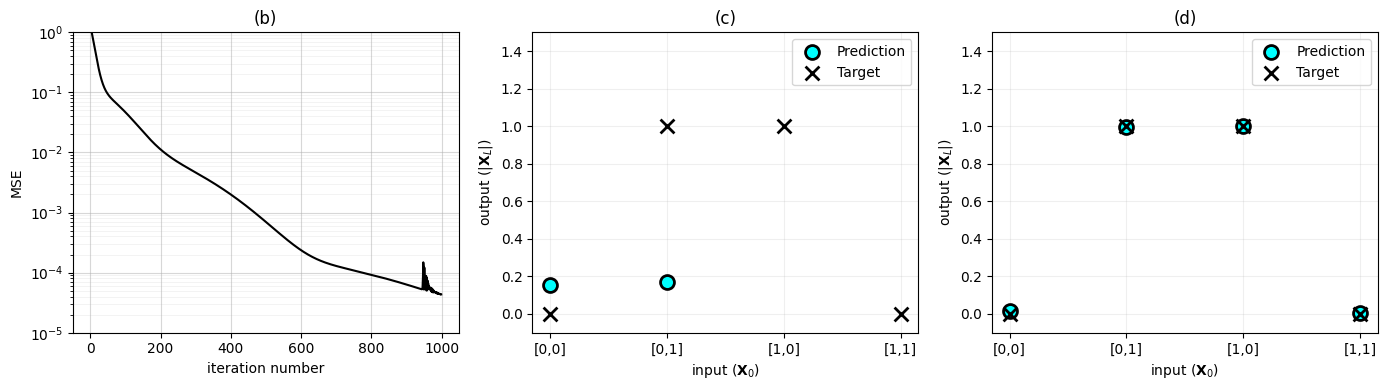


Results:
Input     | Target | Prediction           | Error
--------------------------------------------------
[0 0]      |  0.000 | (0.015769614909357698-0.005468057492364278j) | 0.016691
[0 1]      |  1.000 | (0.9973112301918007-0.0007509587198532103j) | 0.002792
[1 0]      |  1.000 | (1.0001533073042994-0.0012705989359717352j) | 0.001280
[1 1]      |  0.000 | (0.00694898025949126+0.0030226063052380707j) | 0.007578


In [247]:
# Predictions after training
Y_pred_after = model.forward_pass(X_0.T).T.flatten()

# Create figure with 3 subplots like in the paper
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

# (b) MSE vs iteration
ax1.plot(losses, 'k-', linewidth=1.5)
ax1.set_xlabel('iteration number')
ax1.set_ylabel('MSE')
ax1.set_yscale('log')
ax1.set_ylim(bottom=1e-5, top=1e0) # Set y-axis limits
ax1.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)
ax1.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=0.8)
ax1.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)
ax1.set_title('(b)')

# (c) Before training
x_labels = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
x_pos = np.arange(len(X_xor))
ax2.scatter(x_pos, np.abs(Y_pred_before), s=100, c='cyan', edgecolors='black', linewidths=2, label='Prediction', zorder=3)
ax2.scatter(x_pos, T, s=100, marker='x', c='black', linewidths=2, label='Target', zorder=3)
ax2.set_xlabel('input ($\\mathbf{X}_0$)')
ax2.set_ylabel('output ($|\\mathbf{X}_L|$)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels)
ax2.set_ylim(-0.1, 1.5)
ax2.grid(True, alpha=0.2)
ax2.set_title('(c)')
ax2.legend()

# (d) After training
ax3.scatter(x_pos, np.abs(Y_pred_after), s=100, c='cyan', edgecolors='black', linewidths=2, label='Prediction', zorder=3)
ax3.scatter(x_pos, T, s=100, marker='x', c='black', linewidths=2, label='Target', zorder=3)
ax3.set_xlabel('input ($\\mathbf{X}_0$)')
ax3.set_ylabel('output ($|\\mathbf{X}_L|$)')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(x_labels)
ax3.set_ylim(-0.1, 1.5)
ax3.grid(True, alpha=0.2)
ax3.set_title('(d)')
ax3.legend()

plt.tight_layout()
plt.show()

# Print results table
print("\nResults:")
print("Input     | Target | Prediction           | Error") # Adjusted column width
print("-" * 50)
for i, x in enumerate(X_xor):
    prediction_value = Y_pred_after[i]
    error = np.abs(T[i] - prediction_value)
    print(f"{str(x):10} | {T[i]:6.3f} | {str(prediction_value):20} | {error:.6f}")

## References

Bartlett, B., Minkov, M., Hughes, T., & Williamson, I. A. D. (2019).  
*Neuroptica: Flexible simulation package for optical neural networks*.  
GitHub repository.  
Available at: https://github.com/fancompute/neuroptica  
Commit: 06484f698ee038eeb128cdfbd4c59a7e96185bb4
